1. DBSCAN noise points have label -1, so I remove all the -1 noise samples.   
Checking the PCA loading coefficients to interpret what each PC represents is indeed convenient, but in reality many small features in a PC cannot be directly linked to style. So at the moment, I can only rely on plotting the PCs and deducing what style the two ends of each PC correspond to.

2. Plot PC1 and PC2.
Use known players to judge what styles the axes correspond to + examine the main contributing features of these two axes.
I want to use Plotly here so the points are interactive and verifiable.

3. Plot PC3 and PC4.
Again, use known players to infer the styles + look at their contributing features.

4. Pseudo-labels:
Assign labels to players who are extreme on PC1/PC2, and then train multiple classifiers.

5. Feed the noise points from Step 1 (i.e., the ordinary players) into these classifiers to obtain multi-dimensional probability values.

In [2]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina' 
df = pd.read_csv('player_features.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2695 entries, 0 to 2694
Data columns (total 73 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 2695 non-null   int64  
 1   user                       2695 non-null   object 
 2   CenterControlScore         2695 non-null   float64
 3   PieceActivityScore         2695 non-null   float64
 4   KingSafetyScore            2695 non-null   float64
 5   CastlingScore              2695 non-null   float64
 6   KingTropismScore           2695 non-null   float64
 7   KingDefendersScore         2695 non-null   float64
 8   KingPawnShieldScore        2695 non-null   float64
 9   KingZoneControlScore       2695 non-null   float64
 10  KingDiagonalExposureScore  2695 non-null   float64
 11  KingEscapeSquaresScore     2695 non-null   float64
 12  CaptureRatio               2695 non-null   float64
 13  PawnCenter                 2695 non-null   float

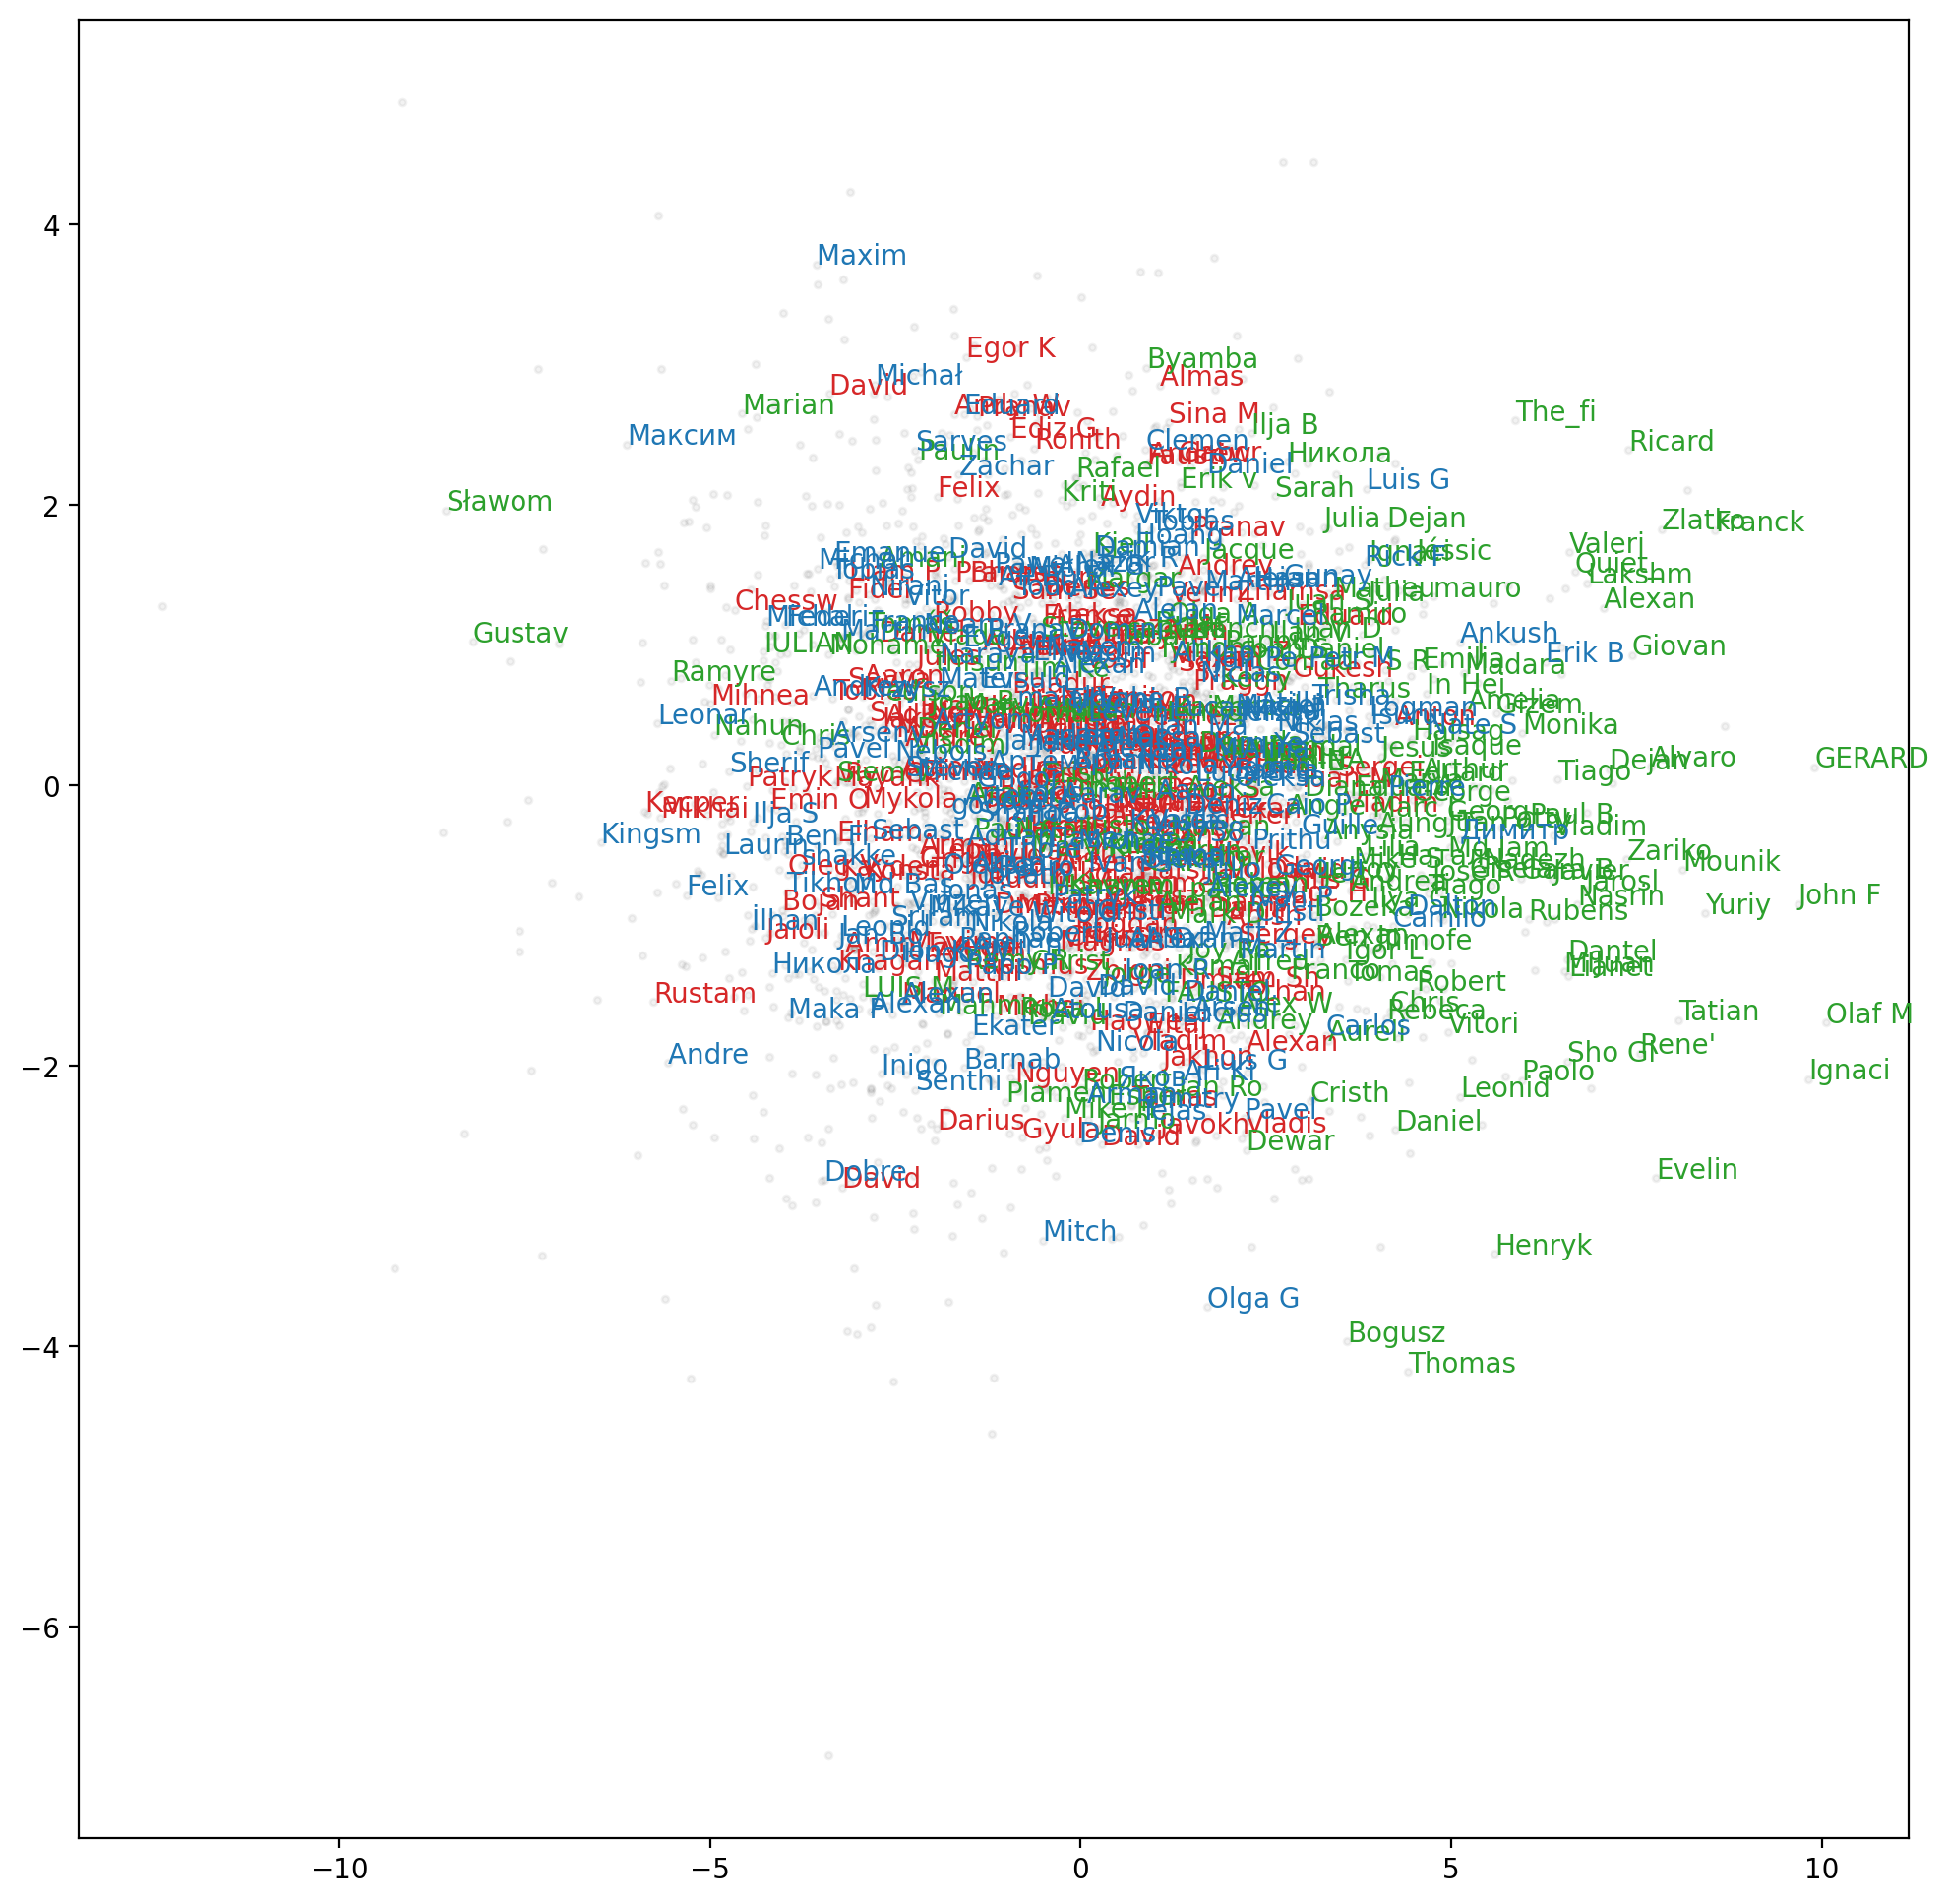

In [8]:
pc1_cols=['CenterControlScore', 'pawn_1LifeRatio', 'PieceActivityScore', 'KingDiagonalExposureScore','pawn_2LifeRatio', 
          'KingSafetyScore', 'KingZoneControlScore', 'queen_1LifeRatio', 
          #'rook_1LifeRatio','rook_2LifeRatio', 'bishop_1LifeRatio','bishop_2LifeRatio', knight_2LifeRatio','pawn_8LifeRatio',
          'knight_1LifeRatio', 'pawn_2LifeRatio', 'pawn_3LifeRatio',
         'KingEscapeSquaresScore', 'AveragePawnAdvanceDepth']
#把所有数字特征都扔到了pca里
cols=list(df.columns[2:20])+list(df.columns[24:47])  #除去了非皇后的升变
df_filt = df[df.TotalGames > 100][pc1_cols].fillna(0).reset_index(drop=True)
# Create the pipeline
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10))
])

# Fit the pipeline and transform the data
X_pca = pca_pipeline.fit_transform(df_filt.values)
num_chosen = 200
lowest_players = df.sort_values(by='ELO').Name[0:num_chosen].values
highest_players = df.sort_values(by='ELO', ascending=False).Name[0:num_chosen].values
medium_players = df.sort_values(by='ELO', ascending=False).Name[int(len(df)/2):int(len(df)/2)+num_chosen].values

plt.figure(figsize=(12,12))
for name in highest_players:
    df_sel = df.reset_index()
    my_id = df_sel[df_sel.user==name].index[0]
    my_name = df_sel[df_sel.user==name].user.values[0]
    plt.text(X_pca[:,0][my_id], X_pca[:,1][my_id], my_name[0:6], c='C3')

for name in lowest_players:
    df_sel = df.reset_index()
    my_id = df_sel[df_sel.user==name].index[0]
    my_name = df_sel[df_sel.user==name].user.values[0]
    plt.text(X_pca[:,0][my_id], X_pca[:,1][my_id], my_name[0:6], c='C2')

for name in medium_players:
    df_sel = df.reset_index()
    my_id = df_sel[df_sel.user==name].index[0]
    my_name = df_sel[df_sel.user==name].user.values[0]
    plt.text(X_pca[:,0][my_id], X_pca[:,1][my_id], my_name[0:6], c='C0')


plt.plot(X_pca[:,0], X_pca[:,1], 'o', alpha=0.05, c='k', ms=2.5)

use DBSCAN to filter out the green noise part

In [9]:
from sklearn.cluster import DBSCAN
from collections import Counter
from sklearn.neighbors import NearestNeighbors
import numpy as np
import plotly.express as px

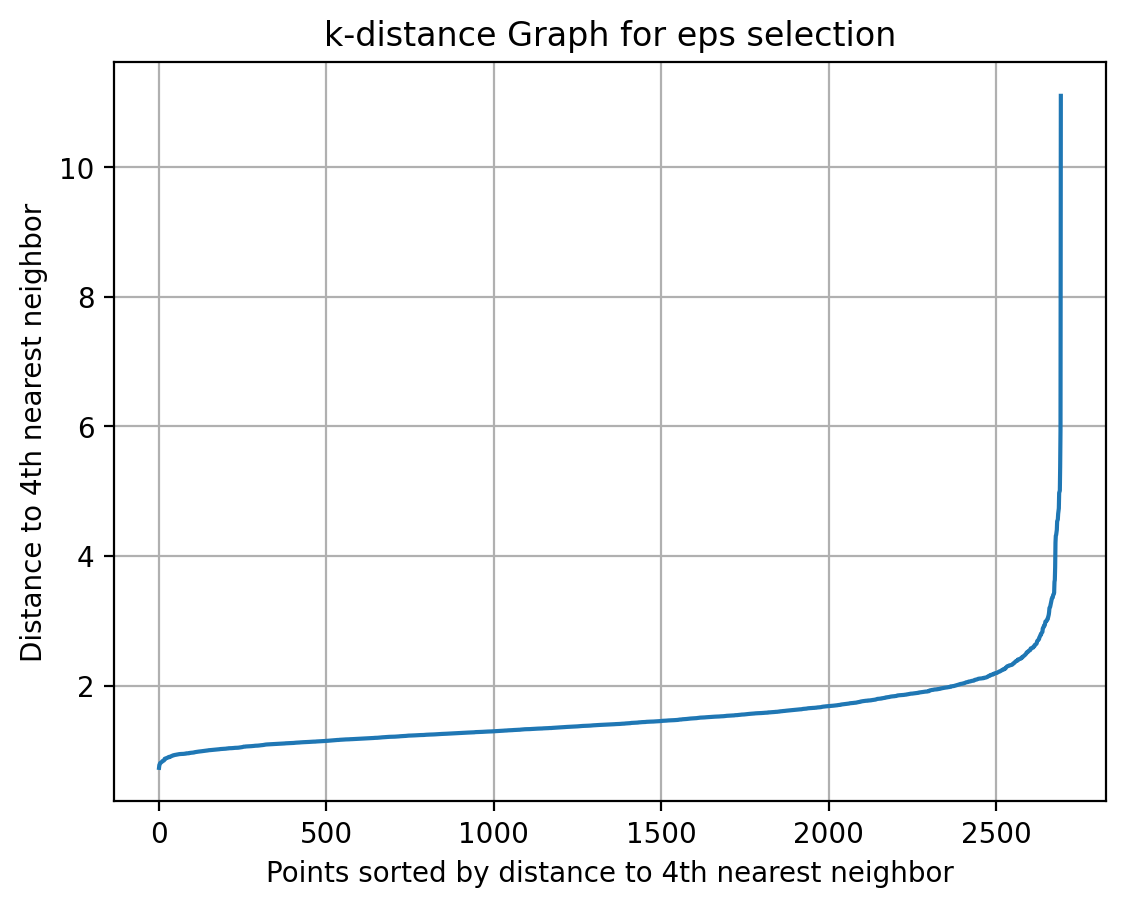

In [10]:
neighbors=NearestNeighbors(n_neighbors=20) #可能还要改
neighbors_fit=neighbors.fit(X_pca)
distance,indices=neighbors_fit.kneighbors(X_pca)
distance=np.sort(distance[:,3])
plt.plot(distance)
plt.xlabel('Points sorted by distance to 4th nearest neighbor')
plt.ylabel('Distance to 4th nearest neighbor')
plt.title('k-distance Graph for eps selection')
plt.grid(True)
plt.show()
#eps选择大概0.5这样

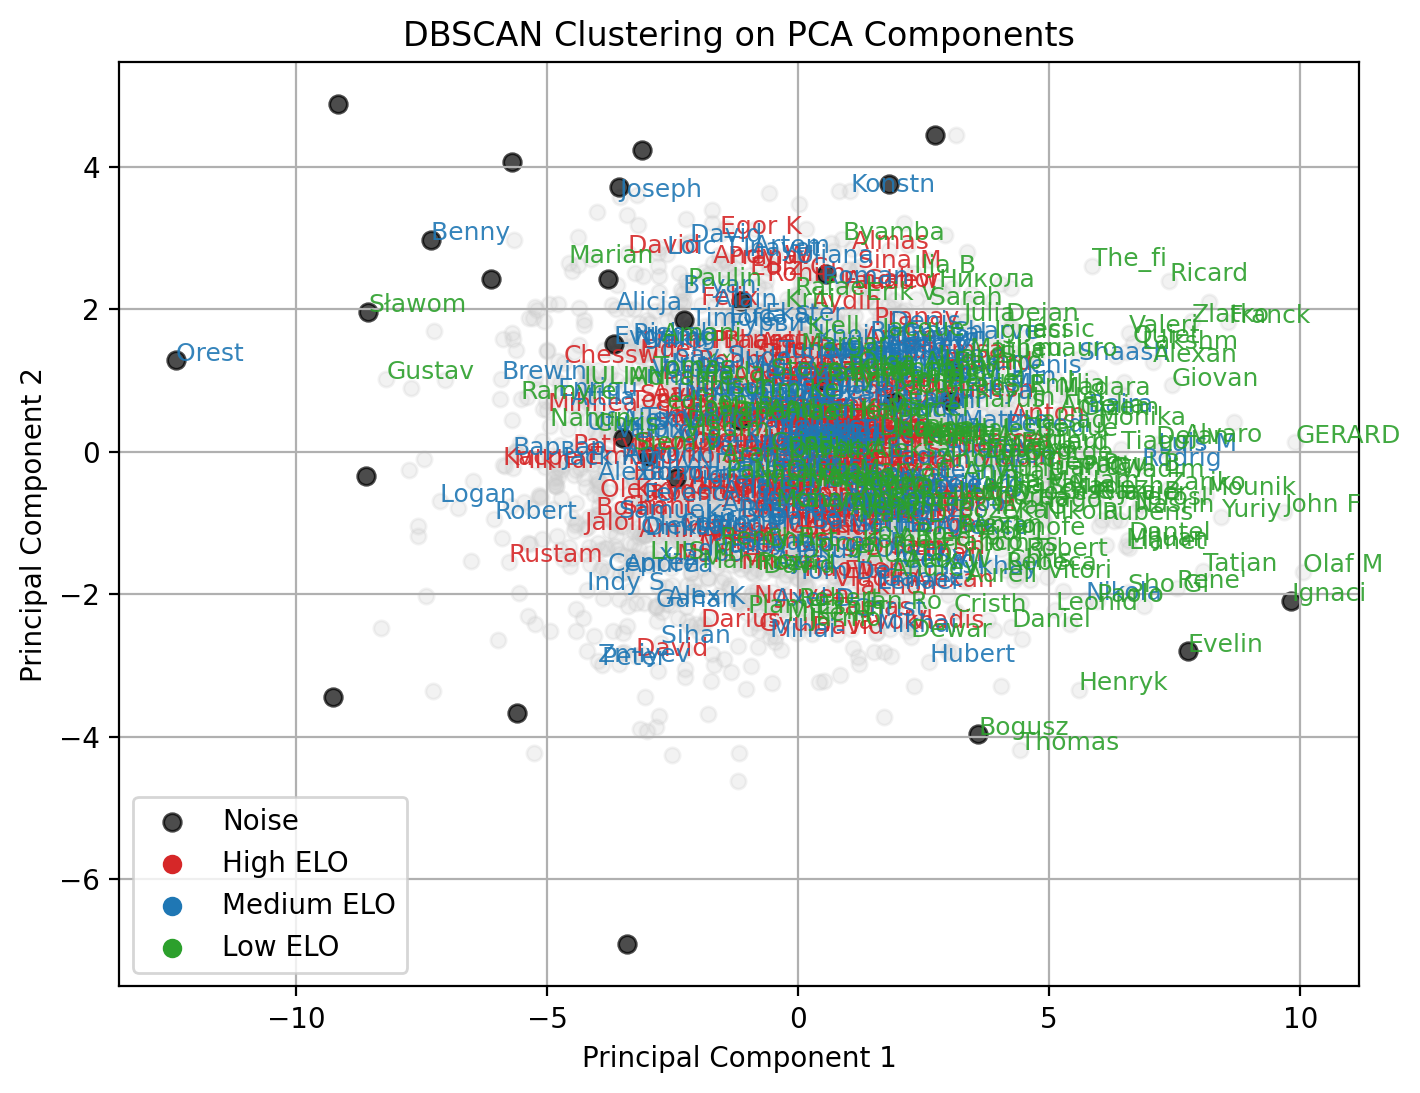

In [11]:
dbscan=DBSCAN(eps=3,min_samples=20)
#让噪声点变多：减小eps，增加min_samples
labels=dbscan.fit_predict(X_pca)
plt.figure(figsize=(8,6))
unique_labels=set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
df_sorted = df.sort_values(by='ELO')
lowest_players  = df_sorted.head(num_chosen).Name.values
highest_players = df_sorted.tail(num_chosen).Name.values
medium_players  = df_sorted.iloc[len(df)//2 : len(df)//2 + num_chosen].Name.values

df_sel = df.reset_index()  # 为了通过名字找到行号

for k in set(labels):
    mask = (labels == k)
    if k == -1:
        # Noise: 黑色
        plt.scatter(X_pca[mask,0], X_pca[mask,1], c='k', s=40, alpha=0.7, label='Noise')
    else:
        # 非噪声 cluster：统一浅灰色
        plt.scatter(X_pca[mask,0], X_pca[mask,1], c='#CCCCCC', s=30, alpha=0.25)

def plot_player_group(player_list, color, label):
    for name in player_list:
        if name not in df_sel.user.values:
            continue
        idx = df_sel[df_sel.user == name].index[0]
        plt.text(
            X_pca[idx, 0], X_pca[idx, 1], name[:6],
            color=color, fontsize=9, alpha=0.9
        )
    plt.scatter([], [], color=color, label=label)  # legend entry

plot_player_group(highest_players, 'C3', 'High ELO')
plot_player_group(medium_players, 'C0', 'Medium ELO')
plot_player_group(lowest_players, 'C2', 'Low ELO')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering on PCA Components')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
#获得这些噪声具体是谁，即noise_players里的人
noise_indices=np.where(labels==-1)[0]
#把噪音里的高水平玩家排除掉，不记为噪音
highest_players_names=df_sorted.tail(num_chosen).Name.values
highest_players_indices = df[df['Name'].isin(highest_players_names)].index.values
noise_indices = [idx for idx in noise_indices if idx not in highest_players_indices]
noise_players=df.iloc[noise_indices][['Name','ELO']]

for index, row in noise_players.iterrows():
    print(row['Name'], row['ELO'])
print(f'rows:{noise_players.shape[0]},columns:{noise_players.shape[1]}')

Alexander Gelman 2763.0
Alexander Spichkin 2413.0
Alexandre Qashashvili 2246.0
Alfeu Junior Varela Bueno 2432.0
Benny Aizenberg 2621.0
Bogusz Piliczewski 1953.0
Dachey Lin 2884.0
Djuro Skaric 2431.0
Evelina Zavivaeva 1583.0
Evgeny Egorov 2626.0
Garnik Nersesyan 2347.0
Ian Dzhumagaliev 2890.0
Ignacio Sainz Aguirre 1939.0
Jesper Kjaergaard-Jensen 2342.0
Jesús Alberto Coca Cubillos 2323.0
Jose Antonio Herrera Reyes 2715.0
Kerry Stead 2078.0
Lily Jeanette Duarte Cramer 2295.0
Maxim Omariev 2603.0
Mohsen Gabr 2652.0
OlegKrivonosov 2729.0
Orest Vovk 2622.0
Ramiro Corona Monraz 1779.0
Robert L. Hess 2876.0
Shamil Arslanov 2905.0
Sławomir Kurpiewski 2139.0
Tabaré Bustelo 1961.0
Thomas Christensen 2211.0
Екатерина Кабанова 2314.0
Максим Матюнин 2574.0
rows:30,columns:2


In [14]:
#df_interpretate打算用来放排除掉噪音点和较差劲玩家的数据
df_interpretate=df.copy()
print(df.shape[0],df.shape[1])
df_interpretate=df_interpretate.drop(noise_indices)
print(df_interpretate.shape[0],df_interpretate.shape[1])
#输出结果正确，刚好差215行
#df_interpretate=df_interpretate[df_interpretate.TotalGames > 100][cols].fillna(0).reset_index(drop=True)
#print(df_interpretate.shape[0],df_interpretate.shape[1])

2695 73
2665 73


In [15]:
print(df['ELO'].describe())
print((df['ELO']>2800).value_counts())  #这个可以调的，选的顶级棋手，免得其实不咋厉害的人反而子维度分很高
df_interpretate=df_interpretate[df_interpretate['ELO']>2800].copy()

count    2695.000000
mean     2607.291280
std       253.227287
min      1533.000000
25%      2452.000000
50%      2604.000000
75%      2777.000000
max      3319.000000
Name: ELO, dtype: float64
ELO
False    2084
True      611
Name: count, dtype: int64


对这些顶级棋手聚类，尝试解释风格

In [16]:
df_interpretate_flit=df_interpretate[df_interpretate.TotalGames>100][cols].fillna(0).reset_index(drop=True)
interpretate_X_pca = pca_pipeline.fit_transform(df_interpretate_flit.values)

In [17]:
df_interpretate_pca = pd.DataFrame({
    "PC1": interpretate_X_pca[:, 0],
    "PC2": interpretate_X_pca[:, 1],
    "Name": df_interpretate.user.values
})

top_highest_players = df_sorted.tail(30).Name.values
#选top玩家
df_interpretate_pca["is_top"] = df_interpretate_pca["Name"].isin(top_highest_players)
#只有top玩家显示文字，其他玩家为空
df_interpretate_pca["text"] = df_interpretate_pca["Name"].where(df_interpretate_pca["is_top"], "")

fig = px.scatter(
    df_interpretate_pca,
    x="PC1",
    y="PC2",
    color="is_top",
    text="text",          #只显示 top 的名字
    hover_name="Name",    #其他一般的玩家只有悬停的时候才显示名字
    opacity=0.6
)
fig.update_traces(textposition="top center")
fig.update_layout(
    width=1200,
    height=900,
    showlegend=False,
    title="Interactive PCA Scatter Plot (Plotly)"
)

fig.update_xaxes(zeroline=True, zerolinewidth=1,zerolinecolor='red')
fig.update_yaxes(zeroline=True, zerolinewidth=1,zerolinecolor='red')

fig.show()

# 筛选 top 玩家
top_coords = df_interpretate_pca[df_interpretate_pca["is_top"]][["Name", "PC1", "PC2"]]

# 打印出来
print(top_coords)

                          Name       PC1       PC2
25              Aleksei Sarana -0.174730 -0.788214
49            Alireza Firouzja  3.057886  0.113765
65               Andy Woodward -0.150656  2.690683
79              Arjun Erigaisi  1.848683  1.347167
113         Bogdan Daniel Deac  0.880021 -2.557896
148              Denis Lazavik  1.021645 -3.490879
159           Dmitry Andreikin  2.963530 -1.696129
166                 Ediz Gürel -1.024025  1.469169
191            Fabiano Caruana  0.512262 -1.248282
193               Faustino Oro  1.167609  0.959548
230               Hans Niemann  1.278006  0.117118
236            Hikaru Nakamura  1.526554 -0.527929
239         Ian Nepomniachtchi  0.424673  0.932850
258           Ivan Zemlyanskii  3.729715 -0.329974
272         Jan-Krzysztof Duda  0.818493  0.377309
274          Javokhir Sindarov  2.701286 -2.000054
339             Magnus Carlsen  1.238129 -1.337230
340           Mahammad Muradli  0.970233 -3.070048
372     Maxime Vachier-Lagrave 

## ♟️ PCA 降维结果解读：棋风分类体系

基于 Titled Tuesday 过去五年数据的 PCA 分析，我们成功提取了两个核心维度来定义棋手的风格。

### ↔️ X轴 (PC1)：局面控制 vs. 战术乱战 (Positional Control vs. Tactical Chaos)
**这一维度衡量的是棋局的“秩序感”与“精确度”。**

* **右侧 (Positive, > 0): 局面统治型 (Dominant / Positional)**
    * **风格描述：** 依靠对中心的绝对控制、协调的子力位置和完整的兵型结构获胜。招法客观精确，接近引擎首选，讲究“秩序”与“压制”。
    * **关键特征：** `CenterControlScore` (中心控制), `PieceActivityScore` (子力活跃), `pawn_1Life/2Life` (结构完整)。
    * **代表棋手：** **Tuan Minh Le, Wesley So, Alireza Firouzja**（表现出极高的统治力和机器般的精确度）。

* **左侧 (Negative, < 0): 战术搏杀型 (Scrappy / Tactical)**
    * **风格描述：** 依靠复杂的战术纠缠、制造混乱（将军/逃跑）和机会主义陷阱获胜。局面往往支离破碎，充满了不确定性和泥潭般的互搏。
    * **关键特征：** `CheckRatio` (将军频率), `KingEscapeSquaresScore` (老王逃跑), `ForceRatio` (剧烈兑子)。
    * **代表棋手：** **Oleksandr Bortnyk, Pranesh M**（擅长在混乱局面中生存和反杀）。

---

### ↕️ Y轴 (PC2)：激进进攻 vs. 稳健防守 (Aggressive vs. Solid)
**这一维度衡量的是棋手的“侵略意图”与“风险偏好”。**

* **上方 (Positive, > 0): 激进突破型 (Aggressive / Dynamic)**
    * **风格描述：** 极具攻击欲望，倾向于冒风险将兵冲至深处（第6/7线）或将车杀入底线，寻求升变或杀王。
    * **关键特征：** `pawn_6LifeRatio`, `pawn_7LifeRatio` (兵冲到底), `rook_2LifeRatio` (车沉底侵略)。
    * **代表棋手：** **Pranesh M, Ian Nepomniachtchi**（锋利的攻击手）。

* **下方 (Negative, < 0): 稳健坚实型 (Solid / Fortress)**
    * **风格描述：** 防守反击风格，兵主要停留在第3/4线构筑坚固防线，注重兵链保护，极大降低输棋风险，像堡垒一样难以攻破。
    * **关键特征：** `pawn_3LifeRatio`, `pawn_4LifeRatio` (兵在低位), `PawnProtectScore` (兵链互保), `rook_1LifeRatio` (底线防守)。
    * **代表棋手：** **Denis Lazavik** (极致的稳健), **Magnus Carlsen** (极强的磨控能力)。

---

### 🧩 四象限风格画像
1.  **右上 (High Control + Aggressive): 全能杀手 (The Lethal Dominators)** —— 既有统治力又极其锋利 (e.g., Firouzja)。
2.  **右下 (High Control + Solid): 叹息之墙 (The Iron Grinders)** —— 统治力强且滴水不漏 (e.g., Carlsen, Lazavik)。
3.  **左上 (High Chaos + Aggressive): 狂战士 (The Berserkers)** —— 局面混乱且进攻凶猛 (e.g., Pranesh M)。
4.  **左下 (High Chaos + Solid): 顽强防守者 (The Tricky Defenders)** —— 局面被动但极难彻底击溃 (e.g., Bortnyk)。

## ♟️ PCA Interpretation: Chess Style Taxonomy

Based on PCA analysis of Titled Tuesday data from the last five years, we define player styles using two principal components.

### ↔️ X-Axis (PC1): Positional Control vs. Tactical Chaos
**Measures the level of "Order" and "Precision" in the game.**

* **Right Side (Positive, > 0): Positional / Dominant**
    * **Description:** Wins through absolute center control, coordinated piece activity, and sound pawn structures. Moves are objective, precise, and engine-correlated.
    * **Key Features:** `CenterControlScore`, `PieceActivityScore`, `pawn_1Life/2Life` (Structure Integrity).
    * **Notable Players:** **Tuan Minh Le, Wesley So, Alireza Firouzja** (Machine-like precision and control).

* **Left Side (Negative, < 0): Tactical / Scrappy**
    * **Description:** Wins through complications, tactical scrambles, and creating chaos (checks/king runs). The position is often messy, relying on swindles or sharp calculations.
    * **Key Features:** `CheckRatio`, `KingEscapeSquaresScore`, `ForceRatio` (High Exchange Rate).
    * **Notable Players:** **Oleksandr Bortnyk, Pranesh M** (Thriving in chaotic, messy positions).

---

### ↕️ Y-Axis (PC2): Aggressive vs. Solid
**Measures "Aggression Intent" and "Risk Appetite".**

* **Top (Positive, > 0): Aggressive / Dynamic**
    * **Description:** High willingness to take risks, pushing pawns deep (6th/7th ranks) and invading with rooks to create mating threats or promotion chances.
    * **Key Features:** `pawn_6LifeRatio`, `pawn_7LifeRatio` (Deep Advancement), `rook_2LifeRatio` (Invasion).
    * **Notable Players:** **Pranesh M, Ian Nepomniachtchi** (Sharp, attacking style).

* **Bottom (Negative, < 0): Solid / Fortress**
    * **Description:** Risk-averse style. Pawns stay on 3rd/4th ranks to build unbreakable chains. Focuses on prophylaxis and restricting the opponent.
    * **Key Features:** `pawn_3LifeRatio`, `pawn_4LifeRatio` (Conservative structure), `PawnProtectScore`, `rook_1LifeRatio` (Defense).
    * **Notable Players:** **Denis Lazavik** (The "Fortress"), **Magnus Carlsen** (Positional grinding).

---

### 🧩 Quadrant Personas
1.  **Top-Right (Control + Aggressive): The Lethal Dominators** —— Surgical precision with killer instinct (e.g., Firouzja).
2.  **Bottom-Right (Control + Solid): The Iron Grinders** —— Unbreakable positional squeeze (e.g., Carlsen, Lazavik).
3.  **Top-Left (Chaos + Aggressive): The Berserkers** —— Messy positions with heavy attacks (e.g., Pranesh M).
4.  **Bottom-Left (Chaos + Solid): The Tricky Defenders** —— Scrappy defense in passive positions (e.g., Bortnyk).

In [18]:
# 1. 提取 PCA 模型
# 如果报错，说明你的 pipeline 最后一步不叫 'pca'，请改为 pca_model = pca_pipeline[-1]
pca_model = pca_pipeline.named_steps['pca'] 

# 获取实际计算出的 PC 数量 (比如你之前设了2，这里就是2)
n_components = pca_model.n_components_
print(f"当前模型包含 {n_components} 个主成分。")

# 2. 提取特征权重 (Loadings)
loadings_df = pd.DataFrame(
    pca_model.components_.T, 
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=cols
)

# ----------------------------------------------------------
# 可视化 A：特征权重热力图
# ----------------------------------------------------------
fig_heatmap = px.imshow(
    loadings_df, 
    labels=dict(x="Principal Components", y="Feature Name", color="Weight"),
    x=loadings_df.columns,
    y=loadings_df.index,
    color_continuous_scale='RdBu_r', 
    zmin=-0.5, zmax=0.5,             
    aspect="auto",
    height=1200,                    
    title=f"Feature Contribution Heatmap ({n_components} PCs)"
)
fig_heatmap.show()

# ----------------------------------------------------------
# 文字输出 B：详细排序 (自动适配 PC 数量)
# ----------------------------------------------------------
print("\n" + "="*50)
print(">>> PCA 主成分特征详细排序 <<<")
print("="*50)

# 循环次数改为 n_components，有多少显示多少，不再强行显示 5 个
for i in range(n_components): 
    pc_name = f"PC{i+1}"
    
    # 排序
    sorted_features = loadings_df[pc_name].sort_values(ascending=False)
    
    print(f"\n【{pc_name} 解析】")
    print(f"  ⬆️ 正向最强特征 (值越大 {pc_name} 越大):")
    print(f"     {', '.join(sorted_features.head(5).index)}")
    
    print(f"  ⬇️ 负向最强特征 (值越小 {pc_name} 越小):")
    print(f"     {', '.join(sorted_features.tail(5).index)}")

当前模型包含 10 个主成分。



>>> PCA 主成分特征详细排序 <<<

【PC1 解析】
  ⬆️ 正向最强特征 (值越大 PC1 越大):
     CenterControlScore, pawn_1LifeRatio, KingDiagonalExposureScore, pawn_2LifeRatio, PieceActivityScore
  ⬇️ 负向最强特征 (值越小 PC1 越小):
     queen_promo_1LifeRatio, ForceRatio, CheckRatio, KingEscapeSquaresScore, AveragePawnAdvanceDepth

【PC2 解析】
  ⬆️ 正向最强特征 (值越大 PC2 越大):
     pawn_6LifeRatio, rook_2LifeRatio, ForceRatio, queen_1LifeRatio, PieceActivityScore
  ⬇️ 负向最强特征 (值越小 PC2 越小):
     KingTropismScore, PawnProtectScore, pawn_3LifeRatio, rook_1LifeRatio, pawn_4LifeRatio

【PC3 解析】
  ⬆️ 正向最强特征 (值越大 PC3 越大):
     PawnProtectScore, pawn_5LifeRatio, queen_promo_4LifeRatio, queen_promo_5LifeRatio, queen_promo_6LifeRatio
  ⬇️ 负向最强特征 (值越小 PC3 越小):
     KingSafetyScore, KingPawnShieldScore, CheckRatio, CaptureRatio, KingTropismScore

【PC4 解析】
  ⬆️ 正向最强特征 (值越大 PC4 越大):
     queen_promo_5LifeRatio, queen_promo_4LifeRatio, queen_promo_6LifeRatio, queen_promo_3LifeRatio, queen_promo_7LifeRatio
  ⬇️ 负向最强特征 (值越小 PC4 越小):
     queen_1LifeRatio, 

# pc1的主要特征
CenterControlScore, pawn_1LifeRatio, PieceActivityScore, KingDiagonalExposureScore, pawn_2LifeRatio， KingSafetyScore,   KingZoneControlScore,queen_1LifeRatio,rook_1LifeRatio,rook_2LifeRatio,bishop_1LifeRatio,bishop_2LifeRatio,knight_1LifeRatio,   knight_2LifeRatio,pawn_2LifeRatio,pawn_3LifeRatio,pawn_8LifeRatio   
   
KingEscapeSquaresScore, AveragePawnAdvanceDepth

In [19]:
pc1_cols=['CenterControlScore', 'pawn_1LifeRatio', 'PieceActivityScore', 'KingDiagonalExposureScore','pawn_2LifeRatio', 
          'KingSafetyScore', 'KingZoneControlScore', 'queen_1LifeRatio', 
          #'rook_1LifeRatio','rook_2LifeRatio', 'bishop_1LifeRatio','bishop_2LifeRatio', knight_2LifeRatio','pawn_8LifeRatio',
          'knight_1LifeRatio', 'pawn_2LifeRatio', 'pawn_3LifeRatio',
         'KingEscapeSquaresScore', 'AveragePawnAdvanceDepth']
#pc1_flit=df_interpretate[df_interpretate.TotalGames > 100][pc1_cols].fillna(0).reset_index(drop=True)
#pc1_X_pca=pca_pipeline.fit_transform(pc1_flit.values)

def run_custom_pca(df, feature_cols, top_players_list, title_suffix="Sub-Analysis", min_games=100):
    """
    参数:
    df: 原始的大 DataFrame (包含 user, TotalGames 和特征列)
    feature_cols: list, 这次PCA分析专门选用的特征列名列表
    top_players_list: list/array, 需要高亮显示的 Top 玩家名字列表
    min_games: int, 筛选场次阈值 (默认 100)
    
    返回:
    fig: Plotly 图表对象
    top_coords: Top 玩家在这个新 PCA 空间下的坐标 DataFrame
    """
    
    # 1. 数据筛选与准备 (注意：Name必须取筛选后的，否则行数对不上)
    # 使用 copy() 避免 SettingWithCopyWarning
    df_filtered = df[df['TotalGames'] > min_games].reset_index(drop=True).copy()
    
    # 提取特征矩阵 X
    X = df_filtered[feature_cols].fillna(0).values
    # 提取对应的名字 (假设你的名字列叫 'user'，如果叫 'Name' 请自行修改)
    names = df_filtered['user'].values 
    
    # 2. 构建 Pipeline (标准化 + PCA)
    # 注意：每次都要重新 fit，因为 feature_cols 的数量变了
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2))
    ])
    
    X_pca = pipeline.fit_transform(X)
    pca = pipeline.named_steps['pca']
    loadings = pca.components_.T
    
    # 打印解释方差比，让你知道这组特征保留了多少信息
    explained_variance = pipeline.named_steps['pca'].explained_variance_ratio_
    print(f"[{title_suffix}] Explained Variance: PC1={explained_variance[0]:.2%}, PC2={explained_variance[1]:.2%}")

     # PCA loadings
    loadings = pca.components_.T   # shape: (n_features, 2)

    loading_df = pd.DataFrame(
        loadings,
        index=feature_cols,
        columns=['PC1_loading', 'PC2_loading']
    )

    # 贡献占比（平方后归一化）
    loading_df['PC1_contribution'] = (
        loading_df['PC1_loading'] ** 2 / (loading_df['PC1_loading'] ** 2).sum()
    )

    loading_df['PC2_contribution'] = (
        loading_df['PC2_loading'] ** 2 / (loading_df['PC2_loading'] ** 2).sum()
    )

    # 按 PC1 贡献度排序（最常用）
    loading_df = loading_df.sort_values('PC1_contribution', ascending=False)

    print(f"\n[{title_suffix}] PC1 Component Contributions:")
    print(loading_df[['PC1_loading', 'PC1_contribution']].head(10))

    print(f"\n[{title_suffix}] PC2 Component Contributions:")
    print(loading_df[['PC2_loading', 'PC2_contribution']].sort_values(
        'PC2_contribution', ascending=False).head(10)
    )

    # 3. 构建绘图用的 DataFrame
    df_plot = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "Name": names
    })
    
    # 4. 标记 Top 玩家
    df_plot["is_top"] = df_plot["Name"].isin(top_players_list)
    # 只有 top 玩家显示文字
    df_plot["text"] = df_plot["Name"].where(df_plot["is_top"], "")
    
    # 5. 绘图
    fig = px.scatter(
        df_plot,
        x="PC1",
        y="PC2",
        color="is_top",
        text="text",
        hover_name="Name",
        opacity=0.6,
        color_discrete_map={True: 'red', False: 'blue'} # 可选：固定颜色
    )
    
    fig.update_traces(textposition="top center")
    fig.update_layout(
        width=1500,
        height=1500,
        showlegend=False,
        title=f"PCA Analysis: {title_suffix}"
    )
    
    fig.update_xaxes(zeroline=True, zerolinewidth=1, zerolinecolor='red')
    fig.update_yaxes(zeroline=True, zerolinewidth=1, zerolinecolor='red')
    
    top_coords = df_plot[df_plot["is_top"]][["Name", "PC1", "PC2"]].reset_index(drop=True)
    
    return fig, top_coords, df_plot

# 0. 准备基础数据 (全局只用做一次)
# 假设你的 Top 玩家列表是这样的
top_highest_players = df_sorted.tail(30).Name.values 

#对 PC1 相关的特征画图
pc1_cols=['CenterControlScore', 'pawn_1LifeRatio', 'PieceActivityScore', 'KingDiagonalExposureScore','pawn_2LifeRatio', 
          'KingSafetyScore', 'KingZoneControlScore', 'queen_1LifeRatio', 
          #'rook_1LifeRatio','rook_2LifeRatio', 'bishop_1LifeRatio','bishop_2LifeRatio', knight_2LifeRatio','pawn_8LifeRatio',
          'knight_1LifeRatio', 'pawn_2LifeRatio', 'pawn_3LifeRatio',
         'KingEscapeSquaresScore', 'AveragePawnAdvanceDepth']

fig1, coords1, pca_df = run_custom_pca(
    df=df_interpretate, 
    feature_cols=pc1_cols, 
    top_players_list=top_highest_players, 
    title_suffix="PC1 Features Group"
)

fig1.show()
print("PC1 Group Top Players Coords:\n", coords1.head(30))

[PC1 Features Group] Explained Variance: PC1=50.89%, PC2=16.40%

[PC1 Features Group] PC1 Component Contributions:
                           PC1_loading  PC1_contribution
pawn_2LifeRatio               0.324351          0.105203
pawn_2LifeRatio               0.324351          0.105203
pawn_1LifeRatio               0.307334          0.094454
CenterControlScore            0.298928          0.089358
PieceActivityScore            0.288963          0.083500
queen_1LifeRatio              0.270102          0.072955
KingDiagonalExposureScore     0.268639          0.072167
KingSafetyScore               0.266702          0.071130
knight_1LifeRatio             0.263766          0.069573
AveragePawnAdvanceDepth      -0.261893          0.068588

[PC1 Features Group] PC2 Component Contributions:
                         PC2_loading  PC2_contribution
queen_1LifeRatio            0.436228          0.190295
KingSafetyScore            -0.415368          0.172531
KingEscapeSquaresScore     -0.385296      

PC1 Group Top Players Coords:
                          Name       PC1       PC2
0              Aleksei Sarana  0.197225 -0.122728
1            Alireza Firouzja  2.318221  0.188261
2               Andy Woodward -1.128545  3.135343
3              Arjun Erigaisi  0.049304  1.470678
4          Bogdan Daniel Deac  0.979802 -1.721492
5               Denis Lazavik  1.486223 -1.559767
6            Dmitry Andreikin  2.607205 -1.668403
7                  Ediz Gürel -0.241382  3.142715
8             Fabiano Caruana  0.411738 -0.225656
9                Faustino Oro  2.144151  2.570675
10               Hans Niemann  0.693134 -1.413417
11            Hikaru Nakamura  0.592216 -0.094313
12         Ian Nepomniachtchi  0.212912  0.348993
13           Ivan Zemlyanskii  3.092375  0.752339
14         Jan-Krzysztof Duda  0.191108  0.203380
15          Javokhir Sindarov  2.351563 -3.189684
16             Magnus Carlsen  0.716045 -1.889312
17           Mahammad Muradli  1.277110  0.094759
18     Maxime Vachi

In [20]:
percent_10=int(len(pca_df)*0.1)
print(percent_10)
solid_positive_players=pca_df.sort_values("PC2", ascending=True).head(percent_10)
solid_positive_names=solid_positive_players['Name'].tolist()
print(solid_positive_names)
solid_negative_players=pca_df.sort_values("PC2", ascending=False).head(percent_10)
solid_negative_names=solid_negative_players['Name'].tolist()
print(solid_negative_names)

60
['Yaacov Norowitz', 'Alexander Khlebovich', 'Markus Ragger', 'Alexandr Triapishko', 'Daniil Lintchevski', 'Aleksandr Lenderman', 'David Paravyan', 'Varuzhan Akobian', 'Dariusz Swiercz', 'Javokhir Sindarov', 'PavelShkapenko', 'Gata Kamsky', 'Dmitry Kryakvin', 'David Navara', 'Boris Grachev', 'Alexey Jarovinsky', 'German Bazeev', 'Vladislav Artemiev', 'Gyula Pap', 'Rustam Khusnutdinov', 'Alexander Grischuk', 'Vladislav Kovalev', 'Aradhya Garg', 'Igor Lysyj', 'Gilbert Elroy Tarigan', 'Nguyen Ngoc Truong Son', 'Vignesh N.R', 'Ivan Povshednyi', 'Tamas Banusz', 'Alexey Dreev', 'Gnel Melikyan', 'Zviad Izoria', 'Itgelt Khuyagtsogt', 'VladimirKramnik', 'Валерий Свиридов', 'Visakh NR', 'Dmitry MIschuk', 'Jakub Pulpan', 'Havard Haug', 'Haowen Xue', 'Eltaj Safarli', 'Roman Yanchenko', 'Jakhongir Vakhidov', 'Aman Hambleton', 'Sebastien Maze', 'Jan Gustafsson', 'Abdulla Gadimbayli', 'Matthias Bluebaum', 'Alexander Rustemov', 'Leonid Starozhilov', 'Evgeny Alekseev', 'Grigor Grigorov', 'Magnus Carl

Hypothesis Testing on chaos and solid players

In [21]:
from scipy import stats

scaler=StandardScaler()
check_cols=['queen_1LifeRatio','KingSafetyScore','KingEscapeSquaresScore','PieceActivityScore','KingZoneControlScore','pawn_3LifeRatio','AveragePawnAdvanceDepth',
'pawn_2LifeRatio','CenterControlScore']
df_interpretate[check_cols] = scaler.fit_transform(df_interpretate[check_cols])   
df_interpretate=df_interpretate.fillna(0)
#伪标签分组
group_solid_df=df_interpretate[df_interpretate['Name'].isin(solid_positive_names)]
group_chaos_df=df_interpretate[df_interpretate['Name'].isin(solid_negative_names)]
print(f"检测到 Solid 组人数: {len(group_solid_df)}")
print(f"检测到 Chaos 组人数: {len(group_chaos_df)}")

#假设检验 (T-test)
results_list = []
for col in check_cols:
    data_solid = group_solid_df[col].dropna()
    data_chaos = group_chaos_df[col].dropna()
    
    # 只有当两组都有数据时才跑检验
    if len(data_solid) > 1 and len(data_chaos) > 1:
        t_stat, p_val = stats.ttest_ind(data_solid, data_chaos, equal_var=False)
        
        mean_solid = data_solid.mean()
        mean_chaos = data_chaos.mean()
        if mean_solid > mean_chaos:
            trend = "Solid > Chaos"
        else:
            trend = "Chaos > Solid"
            
        # 判断显著性 (P < 0.05)
        significance = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "不显著"))

        results_list.append({
            "特征名 (Feature)": col,
            #"显著性(significance)": significance,
            "P值 (p-value)": p_val,
            "趋势 (Trend)": trend,
            "Solid's Mean Value'": mean_solid,
            "Chaos's Mean Value'": mean_chaos
        })
    else:
        print(f"警告: 特征 {col} 数据不足，跳过检验。")

#结果表
hypothesis_df = pd.DataFrame(results_list)

#P值从小到大排序 (P值越小越重要)
if not hypothesis_df.empty:
    hypothesis_df = hypothesis_df.sort_values(by="P值 (p-value)")
    pd.set_option('display.float_format', lambda x: '%.5f' % x)
    print("\n假设检验结果 (按显著性排序)")
    print(hypothesis_df.to_string())
    #hypothesis_df.to_csv("style_hypothesis_test.csv", index=False)
else:
    print("没有生成结果，请检查名单里的名字是否在df_interpretate里。")

检测到 Solid 组人数: 60
检测到 Chaos 组人数: 60

假设检验结果 (按显著性排序)
             特征名 (Feature)  P值 (p-value)     趋势 (Trend)  Solid's Mean Value'  Chaos's Mean Value'
0         queen_1LifeRatio       0.00000  Chaos > Solid             -1.18421              1.08672
1          KingSafetyScore       0.00000  Solid > Chaos              1.08952             -1.19933
2   KingEscapeSquaresScore       0.00000  Solid > Chaos              1.01617             -1.04439
3       PieceActivityScore       0.00000  Chaos > Solid             -1.02965              0.85977
4     KingZoneControlScore       0.00000  Solid > Chaos              0.91739             -0.91560
5          pawn_3LifeRatio       0.00000  Solid > Chaos              0.43745             -0.82262
6  AveragePawnAdvanceDepth       0.00000  Solid > Chaos              0.46149             -0.57262
7          pawn_2LifeRatio       0.00000  Solid > Chaos              0.36251             -0.65179
8       CenterControlScore       0.00000  Chaos > Solid          

# PC2的主要特征

In [63]:
pc2_cols=['rook_2LifeRatio','pawn_6LifeRatio','PawnProtectScore','rook_1LifeRatio','pawn_3LifeRatio','pawn_4LifeRatio',
          'PieceActivityScore','KingSafetyScore','KingTropismScore','AveragePawnAdvanceDepth','ForceRatio','PawnIsolateScore','KingPawnShieldScore',
          'queen_1LifeRatio','pawn_7LifeRatio']
fig2, coords2, pca_df2 = run_custom_pca(
    df=df_interpretate, 
    feature_cols=pc2_cols, 
    top_players_list=top_highest_players, 
    title_suffix="PC2 Features Group"
)

fig2.show()
print("PC2 Group Top Players Coords:\n", coords2.head(30))

[PC2 Features Group] Explained Variance: PC1=26.98%, PC2=20.44%

[PC2 Features Group] PC1 Component Contributions:
                         PC1_loading  PC1_contribution
pawn_3LifeRatio              0.37944           0.14398
KingSafetyScore              0.37783           0.14276
rook_1LifeRatio              0.34103           0.11630
PieceActivityScore           0.32891           0.10818
KingTropismScore             0.30130           0.09078
queen_1LifeRatio             0.29723           0.08835
AveragePawnAdvanceDepth     -0.27782           0.07718
pawn_4LifeRatio              0.24744           0.06123
KingPawnShieldScore          0.23412           0.05481
rook_2LifeRatio              0.22947           0.05266

[PC2 Features Group] PC2 Component Contributions:
                         PC2_loading  PC2_contribution
rook_2LifeRatio              0.38198           0.14591
pawn_6LifeRatio              0.36693           0.13464
AveragePawnAdvanceDepth     -0.31749           0.10080
pawn_4Lif

PC2 Group Top Players Coords:
                          Name      PC1      PC2
0              Aleksei Sarana -0.34587 -1.46953
1            Alireza Firouzja  1.63041  0.49199
2               Andy Woodward -0.29999  1.25981
3              Arjun Erigaisi  0.13476  0.49046
4          Bogdan Daniel Deac  1.10826 -2.27612
5               Denis Lazavik  1.27861 -2.88320
6            Dmitry Andreikin  2.45366 -1.50269
7                  Ediz Gürel -0.83007  0.61623
8             Fabiano Caruana  0.42416 -0.81209
9                Faustino Oro  1.25950  1.92462
10               Hans Niemann  0.32664  0.58732
11            Hikaru Nakamura  0.27320 -0.49100
12         Ian Nepomniachtchi  0.18884  1.05840
13           Ivan Zemlyanskii  3.12390 -0.33032
14         Jan-Krzysztof Duda  0.04135 -0.61179
15          Javokhir Sindarov  1.84360 -0.70019
16             Magnus Carlsen  0.76838 -1.36874
17           Mahammad Muradli  0.71500 -3.22206
18     Maxime Vachier-Lagrave  0.62995 -1.46363
19       

# PC3风格特征分析   
x轴最右边 structual-Continuity/ Gradual Accumulation
x轴最左边： Forcing

In [22]:
pc3_cols=['KingSafetyScore','KingTropismScore','KingPawnShieldScore','CaptureRatio','CheckRatio','ForceRatio',
          'PawnProtectScore','bishop_1LifeRatio','pawn_5LifeRatio','queen_promo_2LifeRatio','queen_promo_3LifeRatio',
          #'queen_promo_4LifeRatio','queen_promo_5LifeRatio','queen_promo_6LifeRatio'
          ]
fig3, coords3, pca_df3 = run_custom_pca(
    df=df_interpretate, 
    feature_cols=pc3_cols, 
    top_players_list=top_highest_players, 
    title_suffix="PC3 Features Group"
)

fig3.show()
print("PC3 Group Top Players Coords:\n", coords3.head(30))

[PC3 Features Group] Explained Variance: PC1=24.43%, PC2=21.51%

[PC3 Features Group] PC1 Component Contributions:
                        PC1_loading  PC1_contribution
PawnProtectScore            0.48618           0.23637
CheckRatio                 -0.46685           0.21795
pawn_5LifeRatio             0.42161           0.17776
ForceRatio                 -0.37334           0.13939
bishop_1LifeRatio           0.30848           0.09516
CaptureRatio               -0.27672           0.07658
KingTropismScore           -0.17497           0.03061
KingPawnShieldScore        -0.14254           0.02032
queen_promo_3LifeRatio     -0.05445           0.00296
KingSafetyScore            -0.03978           0.00158

[PC3 Features Group] PC2 Component Contributions:
                        PC2_loading  PC2_contribution
KingSafetyScore             0.59030           0.34845
KingTropismScore            0.55856           0.31199
KingPawnShieldScore         0.39348           0.15483
CaptureRatio            

PC3 Group Top Players Coords:
                          Name      PC1      PC2
0              Aleksei Sarana  0.03465 -1.22903
1            Alireza Firouzja  1.10738  0.76769
2               Andy Woodward  1.15822 -2.55631
3              Arjun Erigaisi  2.02237 -0.94504
4          Bogdan Daniel Deac  0.30010  1.14131
5               Denis Lazavik  1.14466  1.58364
6            Dmitry Andreikin -0.41071  2.19279
7                  Ediz Gürel -2.14540 -0.95742
8             Fabiano Caruana  2.27626  0.07258
9                Faustino Oro  0.30563 -0.85603
10               Hans Niemann  1.11726  0.08814
11            Hikaru Nakamura  3.04622 -0.55824
12         Ian Nepomniachtchi -1.22355  0.37517
13           Ivan Zemlyanskii -0.42457  1.03232
14         Jan-Krzysztof Duda  0.97092 -0.65878
15          Javokhir Sindarov  0.93465  2.64840
16             Magnus Carlsen  0.12060  1.21282
17           Mahammad Muradli  0.98230  0.71656
18     Maxime Vachier-Lagrave  1.01282  0.64993
19       

In [86]:
percent_10=int(len(pca_df3)*0.1)
print(percent_10)
forcing_positive_players=pca_df3.sort_values("PC1", ascending=True).head(percent_10)
forcing_positive_names=forcing_positive_players['Name'].tolist()
print(forcing_positive_names)
forcing_negative_players=pca_df3.sort_values("PC1", ascending=False).head(percent_10)
forcing_negative_names=forcing_negative_players['Name'].tolist()
print(forcing_negative_names)

55
['Zachary Tanenbaum', 'Abdulla Gadimbayli', 'Daniil Lintchevski', 'Artiom Samsonkin', 'Gellert Karacsonyi', 'Artem Bardyk', 'Marco Riehle', 'Beksultan Moldagali', 'Aaron Jacobson', 'David Paravyan', 'Ilan Schnaider', 'Nikolozi Kacharava', 'Emin Ohanyan', 'Satria Duta Cahaya', 'Maxim Lugovskoy', 'Sahaj Grover', 'Elham Amar', 'Gevorg Harutjunyan', 'Mykola Bortnyk', 'David Navara', 'Łukasz Licznerski', 'Zaur Mammadov', 'Sravan Renjith', 'PavelShkapenko', 'Steven Zierk', 'Farid Orujov', 'Kaivalya Sandip Nagare', 'Matthias Bluebaum', 'Adar TARHAN', 'Yaroslav Remizov', 'Daniil Plyasunov', 'Svyatoslav Lisenkov', 'Mayank Chakraborty', 'Goltsev Dmitry', 'Sathvik Adiga', 'Christopher Woojin Yoo', 'Benik Agasarov', 'David Gavrilescu', 'Igor L. Vakhlamov', 'Silvius Tiberius', 'Eray Kilic', 'Lucas Do Valle Cardoso', 'Mamedov Edgar', 'Maksim Ivannikov', 'Alexei Shirov', 'Lucas Cumpe', 'Leonardo Tristan', 'Ediz Gürel', 'Yagiz Kaan Erdogmus', 'Seyed Abolfazl Moosavifar', 'Eltaj Safarli', 'Khagan Ah

In [88]:
print('Hikaru Nakamura' in(forcing_negative_names))

True


# PC 5 6

In [90]:
pc5_cols=['CastlingScore','KingPawnShieldScore','KingDiagonalExposureScore','KingEscapeSquaresScore','PawnIsolateScore','PawnOverlapScore',
          'pawn_6LifeRatio','pawn_7LifeRatio','pawn_4LifeRatio','pawn_5LifeRatio']
fig5, coords5, pca_df5 = run_custom_pca(
    df=df_interpretate, 
    feature_cols=pc5_cols, 
    top_players_list=top_highest_players, 
    title_suffix="PC5 Features Group"
)

fig5.show()
print("PC5 Group Top Players Coords:\n", coords5.head(30))

[PC5 Features Group] Explained Variance: PC1=22.17%, PC2=19.70%

[PC5 Features Group] PC1 Component Contributions:
                           PC1_loading  PC1_contribution
KingDiagonalExposureScore      0.54703           0.29924
pawn_4LifeRatio                0.52558           0.27624
CastlingScore                  0.34136           0.11653
pawn_6LifeRatio               -0.33645           0.11320
KingEscapeSquaresScore        -0.32996           0.10888
pawn_5LifeRatio                0.24589           0.06046
KingPawnShieldScore            0.15162           0.02299
pawn_7LifeRatio                0.04819           0.00232
PawnIsolateScore               0.01196           0.00014
PawnOverlapScore              -0.00185           0.00000

[PC5 Features Group] PC2 Component Contributions:
                           PC2_loading  PC2_contribution
CastlingScore                  0.46351           0.21484
pawn_6LifeRatio                0.41902           0.17558
PawnOverlapScore              -0.395

PC5 Group Top Players Coords:
                          Name      PC1      PC2
0              Aleksei Sarana  1.49813 -0.11720
1            Alireza Firouzja  0.18415  0.54193
2               Andy Woodward  1.25505 -0.21671
3              Arjun Erigaisi  1.77626  2.56663
4          Bogdan Daniel Deac  0.46238  0.14166
5               Denis Lazavik  0.36018 -1.70721
6            Dmitry Andreikin  2.61376 -0.10236
7                  Ediz Gürel -0.21515 -3.07916
8             Fabiano Caruana -0.55955  0.30937
9                Faustino Oro -2.17280 -2.62742
10               Hans Niemann -1.25127  2.43146
11            Hikaru Nakamura  1.11909  1.17368
12         Ian Nepomniachtchi -0.41431  0.81479
13           Ivan Zemlyanskii  2.94903  0.02748
14         Jan-Krzysztof Duda  0.67684  0.78845
15          Javokhir Sindarov -0.68117  0.43615
16             Magnus Carlsen  0.31334  1.27603
17           Mahammad Muradli  1.21827 -2.57758
18     Maxime Vachier-Lagrave -0.38956  0.89077
19       

# Life Only 

In [95]:
pc6_cols=['bishop_1LifeRatio','bishop_2LifeRatio','knight_1LifeRatio','knight_2LifeRatio','rook_1LifeRatio','rook_2LifeRatio',
          'queen_1LifeRatio',
          'pawn_3LifeRatio','pawn_4LifeRatio','pawn_6LifeRatio','pawn_5LifeRatio'
          #'pawn_8LifeRatio','pawn_7LifeRatio','pawn_6LifeRatio','pawn_5LifeRatio','pawn_1LifeRatio','pawn_2LifeRatio'
          ]
fig6, coords6, pca_df6 = run_custom_pca(
    df=df_interpretate, 
    feature_cols=pc6_cols, 
    top_players_list=top_highest_players, 
    title_suffix="PC6 Features Group"
)

fig6.show()
print("PC6 Group Top Players Coords:\n", coords6.head(30))

[PC6 Features Group] Explained Variance: PC1=34.60%, PC2=18.92%

[PC6 Features Group] PC1 Component Contributions:
                   PC1_loading  PC1_contribution
knight_1LifeRatio      0.38453           0.14786
queen_1LifeRatio       0.36620           0.13410
bishop_1LifeRatio      0.34969           0.12228
pawn_3LifeRatio        0.32480           0.10549
knight_2LifeRatio      0.31604           0.09988
bishop_2LifeRatio      0.30448           0.09271
rook_1LifeRatio        0.28394           0.08062
pawn_5LifeRatio        0.26919           0.07246
rook_2LifeRatio        0.26549           0.07049
pawn_4LifeRatio        0.25963           0.06741

[PC6 Features Group] PC2 Component Contributions:
                   PC2_loading  PC2_contribution
pawn_6LifeRatio        0.56925           0.32404
pawn_4LifeRatio       -0.45120           0.20358
rook_2LifeRatio        0.41794           0.17467
rook_1LifeRatio       -0.29016           0.08419
pawn_3LifeRatio       -0.27672           0.07658
b

PC6 Group Top Players Coords:
                          Name      PC1      PC2
0              Aleksei Sarana  0.31749 -2.18595
1            Alireza Firouzja  2.58248  0.87258
2               Andy Woodward  1.38301  0.12304
3              Arjun Erigaisi  2.10027  0.83107
4          Bogdan Daniel Deac  0.51747 -1.82391
5               Denis Lazavik  0.66105 -2.45558
6            Dmitry Andreikin  1.86746 -1.63650
7                  Ediz Gürel -1.13497  0.03356
8             Fabiano Caruana  0.70684  0.35138
9                Faustino Oro  0.50884  1.27499
10               Hans Niemann  0.49004  1.40999
11            Hikaru Nakamura  1.89899  0.50941
12         Ian Nepomniachtchi -0.33989  0.90603
13           Ivan Zemlyanskii  2.38619 -1.88879
14         Jan-Krzysztof Duda  1.59598  0.31433
15          Javokhir Sindarov  1.12117  0.36994
16             Magnus Carlsen  1.27592 -0.14505
17           Mahammad Muradli  1.32383 -2.46411
18     Maxime Vachier-Lagrave  0.78369 -0.96162
19       

In [98]:
pc6_cols=['queen_promo_1LifeRatio','queen_promo_2LifeRatio','queen_promo_3LifeRatio',
          'queen_1LifeRatio',
          'pawn_3LifeRatio','pawn_4LifeRatio','pawn_6LifeRatio','pawn_5LifeRatio',
          'pawn_8LifeRatio','pawn_7LifeRatio','pawn_6LifeRatio','pawn_5LifeRatio','pawn_1LifeRatio','pawn_2LifeRatio'
          ]
fig6, coords6, pca_df6 = run_custom_pca(
    df=df_interpretate, 
    feature_cols=pc6_cols, 
    top_players_list=top_highest_players, 
    title_suffix="PC6 Features Group"
)

fig6.show()
print("PC6 Group Top Players Coords:\n", coords6.head(30))

[PC6 Features Group] Explained Variance: PC1=24.96%, PC2=19.14%

[PC6 Features Group] PC1 Component Contributions:
                  PC1_loading  PC1_contribution
pawn_3LifeRatio       0.39533           0.15628
pawn_1LifeRatio       0.38983           0.15197
pawn_2LifeRatio       0.38841           0.15086
pawn_4LifeRatio       0.36309           0.13183
queen_1LifeRatio      0.29694           0.08817
pawn_6LifeRatio      -0.25186           0.06343
pawn_6LifeRatio      -0.25186           0.06343
pawn_8LifeRatio       0.24724           0.06113
pawn_5LifeRatio       0.23263           0.05412
pawn_5LifeRatio       0.23263           0.05412

[PC6 Features Group] PC2 Component Contributions:
                  PC2_loading  PC2_contribution
pawn_6LifeRatio       0.48018           0.23057
pawn_6LifeRatio       0.48018           0.23057
pawn_7LifeRatio       0.45845           0.21018
pawn_8LifeRatio       0.38444           0.14780
pawn_4LifeRatio      -0.22006           0.04842
queen_1LifeRatio  

PC6 Group Top Players Coords:
                          Name      PC1      PC2
0              Aleksei Sarana  1.82430 -2.04114
1            Alireza Firouzja  1.25029  0.97208
2               Andy Woodward -1.51563 -1.70544
3              Arjun Erigaisi  0.90213  0.54719
4          Bogdan Daniel Deac  1.47614 -0.89562
5               Denis Lazavik  2.00116 -1.96318
6            Dmitry Andreikin  2.51794 -1.13896
7                  Ediz Gürel -0.04112  0.16229
8             Fabiano Caruana  1.18572 -0.11942
9                Faustino Oro  0.85198  2.22935
10               Hans Niemann  0.28696  2.04157
11            Hikaru Nakamura  1.21535  0.19420
12         Ian Nepomniachtchi -0.28824  1.01078
13           Ivan Zemlyanskii  3.27683 -1.48010
14         Jan-Krzysztof Duda  0.76560  0.02518
15          Javokhir Sindarov  2.19624  1.69137
16             Magnus Carlsen  0.63712 -0.36851
17           Mahammad Muradli  2.44757 -2.32990
18     Maxime Vachier-Lagrave  0.91770 -0.04353
19       

# 1.Dynamic binary classification 
Negetive samples: players at Y-axis's top   
Positive samples: players at Y-axis's bottom    

In [14]:
#get the name lists of positive players abnd negetive players
#use 10% of people to make the classifer to learn
percent_10 = int(len(df_interpretate_pca) *0.1)
print(percent_10)
#positive samples
# 按 y 轴从高到低排序
Dynamic_positive_players = df_interpretate_pca.sort_values("PC2", ascending=False).head(percent_10)
# 只要名字
Dynamic_positive_names = Dynamic_positive_players["Name"].tolist()
print(Dynamic_positive_names)

#negetive samples
Dynamic_negetive_players=df_interpretate_pca.sort_values('PC2',ascending=True).head(percent_10)
Dynamic_negetive_names=Dynamic_negetive_players['Name'].tolist()
print(Dynamic_negetive_names)

55
['Sebastian Mihajlov', 'Aaron Jacobson', 'Deniel Safarov', 'Egor Koshulyan', 'Almas Rakhmatullaev', 'Dachey Lin', 'Sahaj Grover', 'Zachary Tanenbaum', 'Johan-Sebastian Christiansen', 'Nitin Senthilvel', 'Klementy Sychev', 'David Gavrilescu', 'Silvius Tiberius', 'Satria Duta Cahaya', 'Denes Boros', 'Daniel Chan', 'Leo Valle Luis', 'Levy Rozman', 'Krzysztof Jakubowski', 'Lucas Do Valle Cardoso', 'Dominik Horvath', 'Aydin Suleymanli', 'Shahruh Turayev', 'Ilamparthi A R', 'Alexei Shirov', 'Francisco Javier Muñoz', 'Gevorg Harutjunyan', 'Vadym Petrovskyi', 'Maxim Lugovskoy', 'Owen McCoy', 'Kirill Alekseenko', 'Alexander Velikanov', 'Maksim Ivannikov', 'Adar TARHAN', 'Pranesh M', 'Matvey Galchenko', 'Seyed Abolfazl Moosavifar', 'Floryan Eugene', 'Mikhail Antipov', 'Nikolozi Kacharava', 'Maciej Klekowski', 'Abdulla Gadimbayli', 'Emin Ohanyan', 'Bobur Sattarov', 'Andrew Tang', 'Sathvik Adiga', 'Apoorv Kamble', 'Шубин Кирилл', 'Luka Paichadze', 'Alex Fier', 'Sravan Renjith', 'Miłosz Szpar', 

In [18]:
#Dynamic_1_players记录的是对应的选手信息表
Dynamic_1_players= df[df["user"].isin(Dynamic_positive_names)]
Dynamic_0_players=df[df['user'].isin(Dynamic_negetive_names)]

# 2.Positional binary classification 
Negetive samples: players at X-axis's right   
Positive samples: players at X-axis's left  

In [16]:
#get the name lists of positive players abnd negetive players
#use 10% of people to make the classifer to learn
percent_10 = int(len(df_interpretate_pca) *0.1)
print(percent_10)
#positive samples
# 按 x 轴从右到左排序
Positional_positive_players = df_interpretate_pca.sort_values("PC1", ascending=False).head(percent_10)
# 只要名字
Positional_positive_names = Positional_positive_players["Name"].tolist()
print(Positional_positive_names)

#negetive samples
Positional_negetive_players=df_interpretate_pca.sort_values('PC1',ascending=True).head(percent_10)
Positional_negetive_names=Positional_negetive_players['Name'].tolist()
print(Positional_negetive_names)

55
['Anton Korobov', 'Dmitriy Bocharov', 'Peter Svidler', 'Valery Skatchkov', 'Vladimir Seliverstov', 'Andrey Gorovets', 'Zviad Izoria', 'Mohamed Haddouche', 'Eduardo Iturrizaga Bonelli', 'Axel Bachmann', 'Sergei Zhigalko', 'Vladimir Belous', 'Volodymyr Vetoshko', 'Nitin Senthilvel', 'Alexey Reshetnikov', 'Gukesh D', 'Nils Grandelius', 'Alvar Alonso Rosell', 'Eric Hansen', 'Zhamsaran Tsydypov', 'David Howell', 'Krzysztof Jakubowski', 'Matías Pérez Gormaz', 'Renato Quintiliano', 'Rinat Jumabayev', 'Vladislav Artemiev', 'Rafael Leitao', 'Alexander Zubov', 'Pavel Eljanov', 'Marko Nenezic', 'Dmitry Gordievsky', 'Zurab Javakhadze', 'Tuan Minh Le', 'Sergey Grigoriants', 'Jeffery Xiong', 'Alexei Kornev', 'Sethuraman S.P', 'Tomas Laurusas', 'Sam Shankland', 'Roman Kezin', 'Gleb Dudin', 'Christian Gian Karlo Arca', 'Volodar Murzin', 'Alexander Grischuk', 'Alon Mindlin', 'Valery Kazakouski', 'Vitaliy Bernadskiy', 'Raja Rithvik R', 'Mikhail Kobalia', 'Ivan Zemlyanskii', 'Vjacheslav Weetik', 'Sale